In [1]:
import sys, torch
print(sys.executable)
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

/global/u2/d/devanp/envs/tropicalattentiontrials/.venv310/bin/python
Torch: 2.5.1+cu121 | CUDA: True


In [ ]:
import os, sys
print("CWD:", os.getcwd())

In [ ]:
%cd /global/u2/d/devanp/envs/tropicalattentiontrials

In [6]:
import os
print(os.getcwd())
print(os.listdir(".")[:20])  # should include experiment.py, dataloaders.py, models.py

/global/u2/d/devanp/envs/tropicalattentiontrials
['LICENSE', 'jobs_to_do_evaluate.csv', '15_exp', 'dataloaders.py', 'TropicalAttention.py', 'models.py', 'requirements.txt', '.DS_Store', '.venv310', 'run_exp_15.sh', 'README.md', 'jobs_to_do_train.csv', '__pycache__', '.git', 'experiment.py', 'output.log', '.idea']


In [8]:
from experiment import Experiment
from dataloaders import FloydWarshallStepDataset

In [9]:
import os, sys, socket, time
from pathlib import Path

# 1. Point to the repo (adjust if your path is slightly different)
REPO_DIR = Path("/global/u2/d/devanp/envs/tropicalattentiontrials").resolve()
os.chdir(REPO_DIR)
print("CWD:", os.getcwd())

# 2. Make sure Python can import experiment.py, dataloaders.py, models.py
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

# 3. Basic environment info
import torch
print("Host:", socket.gethostname())
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

# 4. Show current git branch so you can confirm you're on one_layer
try:
    import subprocess
    branch = subprocess.check_output(
        ["git", "branch", "--show-current"], cwd=str(REPO_DIR)
    ).decode().strip()
    print("Git branch:", branch)
except Exception as e:
    print("Could not read git branch:", e)

# 5. Quick import check for Experiment and the step dataset
from experiment import Experiment
from dataloaders import FloydWarshallStepDataset

print("Imports OK: Experiment and FloydWarshallStepDataset available.")

CWD: /global/u2/d/devanp/envs/tropicalattentiontrials
Host: nid001008
Python: 3.10.13
Torch: 2.5.1+cu121 | CUDA available: True
Git branch: one_layer
Imports OK: Experiment and FloydWarshallStepDataset available.


In [18]:
import os, time, json
from importlib import reload

import torch
import schedulefree
from schedulefree import radam_schedulefree as rsf

print("CWD:", os.getcwd())
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

# =========================
# 1. Patch schedulefree optimizer (train_mode issue)
# =========================
if not getattr(rsf.RAdamScheduleFree.step, "_patched_train_mode", False):
    _orig_step = rsf.RAdamScheduleFree.step

    def patched_step(self, closure=None):
        # Force train_mode=True on every step, so schedulefree
        # never complains about train/eval mode.
        for g in self.param_groups:
            g["train_mode"] = True
        return _orig_step(self, closure)

    patched_step._patched_train_mode = True
    rsf.RAdamScheduleFree.step = patched_step
    print("✅ Patched schedulefree.RAdamScheduleFree.step(train_mode=True)")
else:
    print("✅ schedulefree.RAdamScheduleFree.step already patched")

# =========================
# 2. Import / reload Experiment and patch _eval_one_epoch
# =========================
import experiment as experiment_mod
reload(experiment_mod)
Experiment = experiment_mod.Experiment

# Save original _eval_one_epoch
_orig_eval = Experiment._eval_one_epoch

def patched_eval(self, *args, **kwargs):
    """
    Wrap the original _eval_one_epoch so that it *always* returns a 3-tuple:
    (loss, metric1, metric2), matching what train_model expects.
    Extra outputs are ignored; missing ones are filled with None.
    """
    out = _orig_eval(self, *args, **kwargs)
    if not isinstance(out, (tuple, list)):
        # Just a scalar loss -> (loss, None, None)
        return out, None, None
    if len(out) >= 3:
        return out[0], out[1], out[2]
    if len(out) == 2:
        return out[0], out[1], None
    if len(out) == 1:
        return out[0], None, None
    # defensive fallback
    return None, None, None

Experiment._eval_one_epoch = patched_eval
print("✅ Patched Experiment._eval_one_epoch to always return 3 values")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================
# 3. Config: 1-layer tropical FW single-step experiment
# =========================
config = dict(
    task="train",
    model_type="tropical",
    dataset_name="FloydWarshallStepDataset",   # single-step dataset Cursor added
    device=device,

    # Model hyperparams
    input_dim=3,        # (D0_ij, i_norm, j_norm)
    d_model=64,
    n_heads=2,
    num_layers=1,       # <-- ONE layer
    dropout=0.0,

    # Data generation
    n_samples=50000,
    length_range=(8, 8),
    value_range=(1, 15),
    noise_prob=0.0,
    adversarial_range=(10, 20),
    target_range="na",
    weight_range="na",

    # Training hyperparams
    batch_size=64,
    num_epochs=80,
    lr=1e-4,
    seed=0,

    # Logging / directories
    top_cat="fw_step_one_layer",
    experiment_type="fw_step_one_layer",
)

print("\nConfig:\n", json.dumps(config, indent=2, default=str))

# =========================
# 4. Build experiment and run training
# =========================
exp = Experiment(**config)

print("\n--- Setting up dataloader ---")
exp.set_dataloader()

print("--- Setting up model ---")
exp.set_model()

print("\n--- Starting training ---")
t0 = time.time()
exp.train_model()   # now uses patched schedulefree + patched _eval_one_epoch
t1 = time.time()

print("\nTraining finished.")
print("Total wall time (seconds):", round(t1 - t0, 2))
print("Artifacts should be under:", config["top_cat"])

CWD: /global/u2/d/devanp/envs/tropicalattentiontrials
Torch: 2.5.1+cu121 | CUDA: True
✅ schedulefree.RAdamScheduleFree.step already patched
✅ Patched Experiment._eval_one_epoch to always return 3 values
Using device: cuda

Config:
 {
  "task": "train",
  "model_type": "tropical",
  "dataset_name": "FloydWarshallStepDataset",
  "device": "cuda",
  "input_dim": 3,
  "d_model": 64,
  "n_heads": 2,
  "num_layers": 1,
  "dropout": 0.0,
  "n_samples": 50000,
  "length_range": [
    8,
    8
  ],
  "value_range": [
    1,
    15
  ],
  "noise_prob": 0.0,
  "adversarial_range": [
    10,
    20
  ],
  "target_range": "na",
  "weight_range": "na",
  "batch_size": 64,
  "num_epochs": 80,
  "lr": 0.0001,
  "seed": 0,
  "top_cat": "fw_step_one_layer",
  "experiment_type": "fw_step_one_layer"
}
FloydWarshallStepDataset_tropical_0.0001_80_20251205_023320

--- Setting up dataloader ---
...setting dataloader...20251205_023320
--- Setting up model ---
...setting model object...20251205_023326

--- Star

Showing plot: fw_step_one_layer/plots/plots_FloydWarshallStepDataset_tropical_0.0001_80_20251205_023320.png


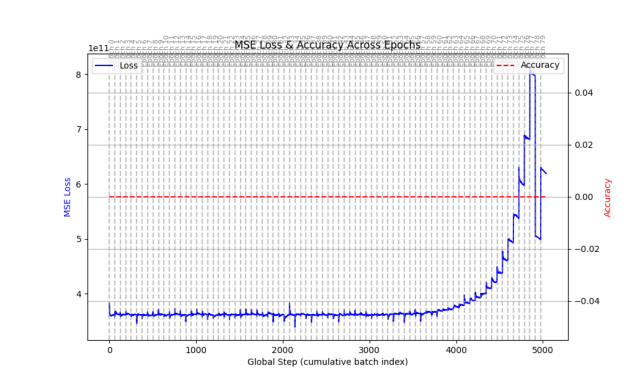

In [23]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

plots_dir = Path("fw_step_one_layer/plots")

if not plots_dir.exists():
    raise FileNotFoundError(f"No plots directory found at {plots_dir.resolve()}")

# Find all PNGs and take the most recently modified one
pngs = sorted(plots_dir.glob("*.png"), key=lambda p: p.stat().st_mtime, reverse=True)

if not pngs:
    raise FileNotFoundError(f"No .png files found in {plots_dir.resolve()}")

latest_plot = pngs[0]
print("Showing plot:", latest_plot)

img = Image.open(latest_plot)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [25]:
import torch
import time, json, traceback, os
from pathlib import Path

from experiment import Experiment

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ------------------------------------------------------------------
# Sweep configuration
# ------------------------------------------------------------------
learning_rates = [1e-4, 3e-4, 1e-3]       # try a few LRs
seeds         = [0, 1, 2]                 # a few random seeds

n_samples   = 500                         # more data than before
num_epochs  = 200                         # longer but still reasonable
batch_size  = 32
length_rng  = (4, 4)                      # fixed n so it's a clean FW step
value_rng   = (1, 15)
adv_rng     = (10, 20)                    # keep as before
noise_prob  = 0.0

top_cat_root = "fw_step_one_layer_sweep"  # all runs live under this folder

# Log file will get updated after each run
log_path = Path(top_cat_root) / "sweep_log.json"
log_path.parent.mkdir(parents=True, exist_ok=True)

results = []

def run_one(seed, lr):
    """
    Run a single config: 1-layer tropical model on FloydWarshallStepDataset
    with a given seed and learning rate, using Adam optimizer.
    """
    exp_name = f"fwstep_lr{lr:g}_seed{seed}"
    print(f"\n==============================")
    print(f"  RUN: {exp_name}")
    print(f"==============================")

    exp = Experiment(
        task="train",
        model_type="tropical",
        dataset_name="FloydWarshallStepDataset",
        # model / training hyperparams
        input_dim=3,
        d_model=64,
        n_heads=2,
        num_layers=1,
        num_epochs=num_epochs,
        dropout=0.0,
        lr=lr,                  # still passed in (for logging, etc.)
        seed=seed,
        n_samples=n_samples,
        batch_size=batch_size,
        # problem-specific knobs
        target_range="na",
        weight_range="na",
        adversarial_range=adv_rng,
        length_range=length_rng,
        noise_prob=noise_prob,
        value_range=value_rng,
        # bookkeeping
        device=device,
        top_cat=top_cat_root,
        experiment_type=exp_name,
    )

    # Standard setup
    exp.set_dataloader()
    exp.set_model()

    # ------------------------------------------------------------------
    # IMPORTANT: override schedulefree with plain Adam to avoid train_mode
    # weirdness, but keep the same LR we’re sweeping over.
    # ------------------------------------------------------------------
    import torch.optim as optim
    exp.optimizer = optim.Adam(exp.model.parameters(), lr=lr)

    # Train (this will also save models + plots via existing Experiment code)
    exp.train_model()


# ----------------------------------------------------------------------
# Main sweep loop with basic fault tolerance
# ----------------------------------------------------------------------
for lr in learning_rates:
    for seed in seeds:
        run_cfg = {
            "lr": lr,
            "seed": seed,
            "n_samples": n_samples,
            "num_epochs": num_epochs,
            "batch_size": batch_size,
            "length_range": length_rng,
            "value_range": value_rng,
            "noise_prob": noise_prob,
            "adversarial_range": adv_rng,
        }

        t0 = time.time()
        status = "ok"
        err_msg = None

        try:
            run_one(seed=seed, lr=lr)
        except Exception as e:
            status = "error"
            err_msg = repr(e)
            print("\n!!! RUN FAILED:", err_msg)
            traceback.print_exc()
        t1 = time.time()

        run_record = {
            "config": run_cfg,
            "status": status,
            "error": err_msg,
            "wall_time_sec": t1 - t0,
        }
        results.append(run_record)

        # Write/update log after every run so partial progress is saved
        with open(log_path, "w") as f:
            json.dump(results, f, indent=2)

print("\n==============================")
print("Sweep finished.")
print("Results log written to:", log_path)
print("==============================")

Device: cuda

  RUN: fwstep_lr0.0001_seed0
FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100
...setting dataloader...20251205_030100
...setting model object...20251205_030100
...training model...20251205_030100
...model saved to fw_step_one_layer_sweep/models/FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100_best.pth...20251205_030101
...model saved to fw_step_one_layer_sweep/models/FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100_best.pth...20251205_030103
...model saved to fw_step_one_layer_sweep/models/FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100_best.pth...20251205_030104
...model saved to fw_step_one_layer_sweep/models/FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100_best.pth...20251205_030104
...model saved to fw_step_one_layer_sweep/models/FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100_best.pth...20251205_030106
...model saved to fw_step_one_layer_sweep/models/FloydWarshallStepDataset_tropical_0.0001_200

In [2]:
from pathlib import Path
import json
import textwrap

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ----------------------------------------------------------------------
# 1. Load sweep log
# ----------------------------------------------------------------------
root = Path("fw_step_one_layer_sweep")
log_path = root / "sweep_log.json"

if not log_path.exists():
    raise FileNotFoundError(f"Could not find {log_path}. Did the sweep finish?")

with open(log_path, "r") as f:
    sweep = json.load(f)

print("Loaded sweep log from:", log_path)
print("Total runs recorded:", len(sweep))

# ----------------------------------------------------------------------
# 2. Print a human-readable summary table
# ----------------------------------------------------------------------
print("\n=== RUN SUMMARY (one-layer FW step, tropical) ===")
for i, r in enumerate(sweep):
    cfg    = r["config"]
    status = r["status"]
    wt     = r.get("wall_time_sec", None)

    print(
        f"[{i:02d}] lr={cfg['lr']:.1e}  seed={cfg['seed']:2d}  "
        f"n_samples={cfg['n_samples']}  epochs={cfg['num_epochs']}  "
        f"status={status.upper()}  "
        + (f"({wt/60:.1f} min)" if wt is not None else "")
    )
    if status != "ok":
        print("     ERROR:", r.get("error", "unknown"))

# Common experiment description (same for all runs in this sweep)
if sweep:
    cfg0 = sweep[0]["config"]
    description = textwrap.dedent(f"""
    Dataset: FloydWarshallStepDataset (single Floyd–Warshall update, k=0)
    Graph size: n in length_range={tuple(cfg0['length_range'])}
    Edge weights: value_range={tuple(cfg0['value_range'])}
    Noise_prob={cfg0['noise_prob']}  adversarial_range={tuple(cfg0['adversarial_range'])}
    Model: 1-layer tropical transformer (SimpleTransformerModel)
           d_model=64, n_heads=2, num_layers=1, dropout=0.0, optimizer=Adam
    Training: n_samples={cfg0['n_samples']}, batch_size={cfg0['batch_size']},
              num_epochs={cfg0['num_epochs']}, device auto-detected.
    """).strip()

    print("\n=== EXPERIMENT DESCRIPTION ===")
    print(description)

# ----------------------------------------------------------------------
# 3. Match each successful run to its plot image (best-effort)
#    We assume each successful run wrote exactly one PNG, in order.
# ----------------------------------------------------------------------
plots_dir = root / "plots"
if not plots_dir.exists():
    raise FileNotFoundError(f"No plots directory found at {plots_dir}")

all_pngs = sorted(plots_dir.glob("*.png"), key=lambda p: p.stat().st_mtime)
ok_runs  = [r for r in sweep if r["status"] == "ok"]

print(f"\nFound {len(all_pngs)} PNGs in {plots_dir}")
print(f"Successful runs in log: {len(ok_runs)}")

# Pair runs with images in chronological order
pairs = []
for run, img_path in zip(ok_runs, all_pngs):
    pairs.append((run, img_path))

if not pairs:
    print("\nNo successful runs with plots to display.")
else:
    print("\nPairing successful runs with plots:")
    for i, (run, img_path) in enumerate(pairs):
        cfg = run["config"]
        print(f"  [{i:02d}] lr={cfg['lr']:.1e}, seed={cfg['seed']}  ->  {img_path.name}")

# ----------------------------------------------------------------------
# 4. Display the plots in a grid with clear titles
# ----------------------------------------------------------------------
if pairs:
    n = len(pairs)
    cols = min(3, n)          # up to 3 columns
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    for (run, img_path), ax in zip(pairs, sum(axes, [])):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis("off")

        cfg = run["config"]
        title = f"LR={cfg['lr']:.1e}, seed={cfg['seed']}\n" \
                f"n_samples={cfg['n_samples']}, epochs={cfg['num_epochs']}"
        ax.set_title(title, fontsize=10)

    # Hide any unused subplots
    for ax in sum(axes, [])[len(pairs):]:
        ax.axis("off")

    fig.suptitle(
        "Floyd–Warshall Single-Step (k=0), One-Layer Tropical Transformer\n"
        + description,
        fontsize=11
    )
    fig.tight_layout(rect=[0, 0, 1, 0.18])
    plt.show()

FileNotFoundError: Could not find fw_step_one_layer_sweep/sweep_log.json. Did the sweep finish?

Sweep root: /global/u2/d/devanp/envs/tropicalattentiontrials/fw_step_one_layer_sweep
Plots dir : /global/u2/d/devanp/envs/tropicalattentiontrials/fw_step_one_layer_sweep/plots
Found 9 runs:

 - plots_FloydWarshallStepDataset_tropical_0.0001_200_20251205_030100.png
 - plots_FloydWarshallStepDataset_tropical_0.0001_200_20251205_030318.png
 - plots_FloydWarshallStepDataset_tropical_0.0001_200_20251205_030537.png
 - plots_FloydWarshallStepDataset_tropical_0.0003_200_20251205_030755.png
 - plots_FloydWarshallStepDataset_tropical_0.0003_200_20251205_031007.png
 - plots_FloydWarshallStepDataset_tropical_0.0003_200_20251205_031219.png
 - plots_FloydWarshallStepDataset_tropical_0.001_200_20251205_031432.png
 - plots_FloydWarshallStepDataset_tropical_0.001_200_20251205_031647.png
 - plots_FloydWarshallStepDataset_tropical_0.001_200_20251205_031901.png


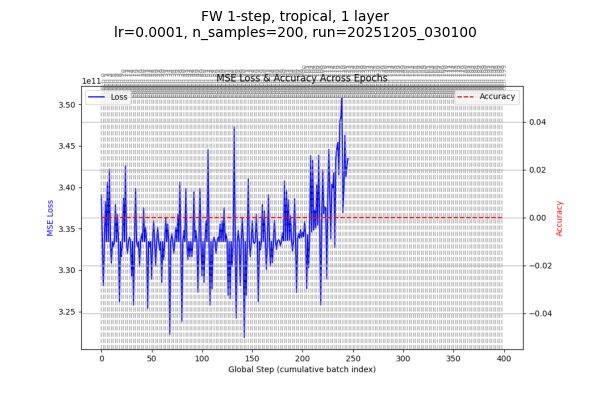

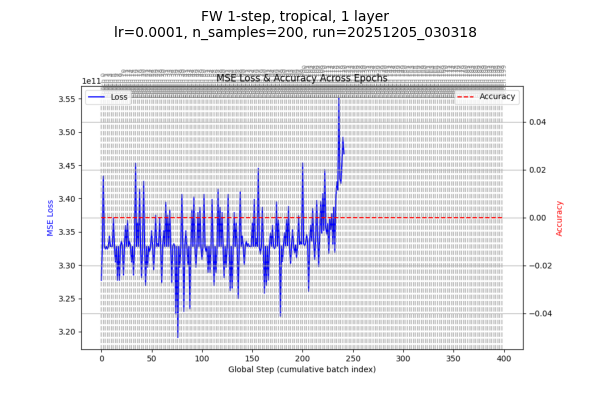

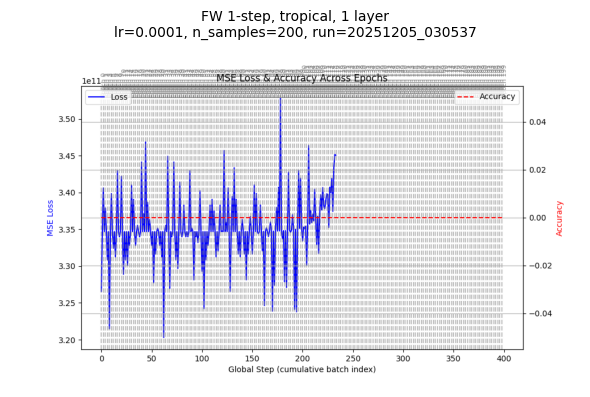

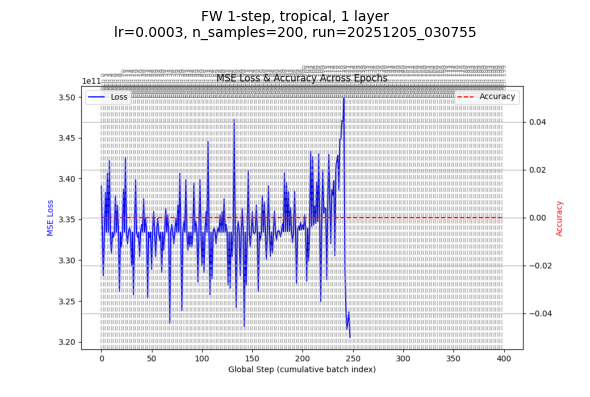

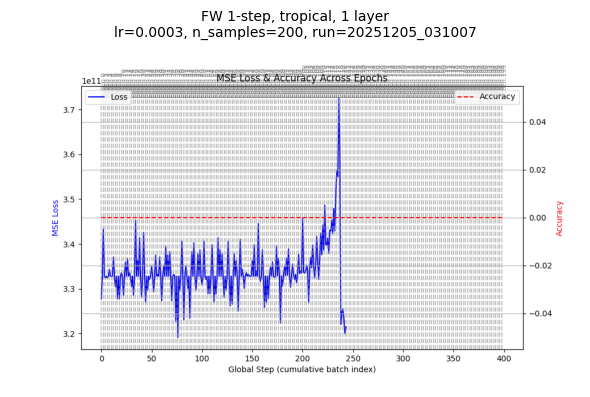

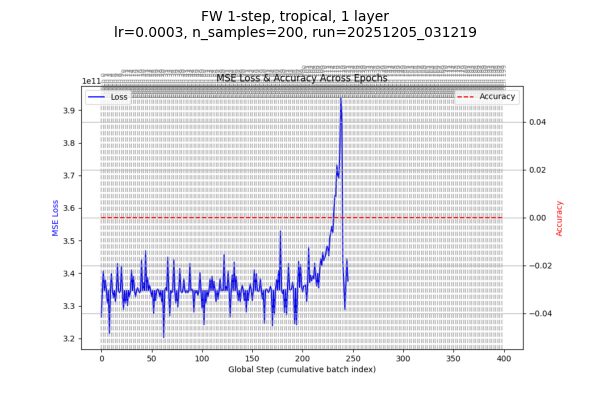

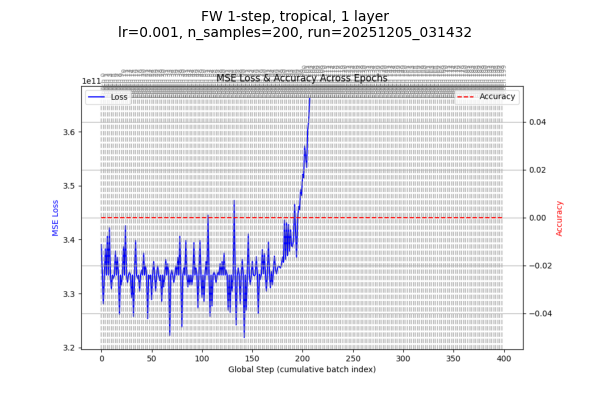

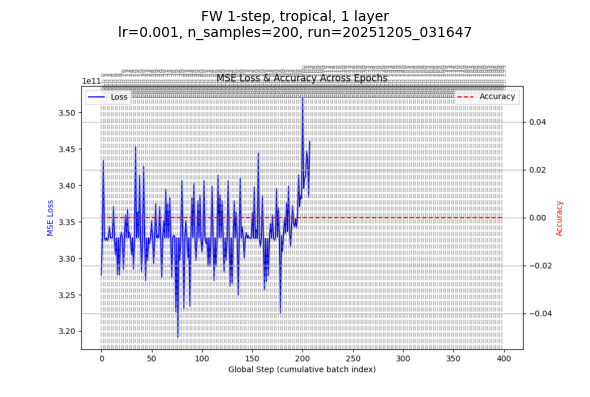

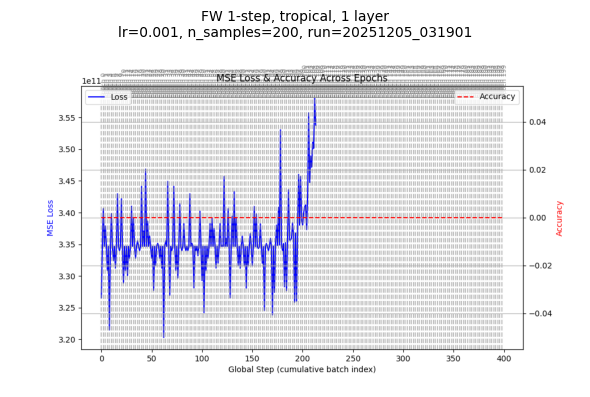

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# ---- 1. Point directly at the sweep directory on disk ----
sweep_root = Path("/global/u2/d/devanp/envs/tropicalattentiontrials/fw_step_one_layer_sweep")
plots_dir = sweep_root / "plots"

print("Sweep root:", sweep_root)
print("Plots dir :", plots_dir)

if not plots_dir.exists():
    raise FileNotFoundError(
        f"Could not find {plots_dir}.\n"
        "If this errors, run in a terminal:\n"
        "  cd ~/envs/tropicalattentiontrials && ls fw_step_one_layer_sweep\n"
        "and tell me what you see."
    )

# ---- 2. Collect all plot PNGs ----
pngs = sorted(plots_dir.glob("plots_FloydWarshallStepDataset_tropical_*.png"))
if not pngs:
    raise FileNotFoundError(f"No PNGs found in {plots_dir}. Check that training completed.")

print(f"Found {len(pngs)} runs:\n")
for p in pngs:
    print(" -", p.name)

# ---- 3. Display them nicely, one after another ----
for p in pngs:
    fig, ax = plt.subplots(figsize=(6, 4))
    img = Image.open(p)
    ax.imshow(img)
    ax.axis("off")
    
    # Derive a human-readable title from the filename
    # e.g. plots_FloydWarshallStepDataset_tropical_0.0003_200_20251205_030755.png
    name_parts = p.stem.split("_")
    lr = name_parts[3]       # learning rate
    n_samples = name_parts[4]
    timestamp = "_".join(name_parts[5:])
    
    ax.set_title(
        f"FW 1-step, tropical, 1 layer\n"
        f"lr={lr}, n_samples={n_samples}, run={timestamp}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()